# CAD — Exploración del dataset TBX11K

Primera etapa del proyecto: entender el dataset antes de pasar a extracción de características y modelos.

**Clases:** `health = 0` · `sick = 1` · `tb = 2`

- Para este proyecto se trabajará con tres clases: Health (0), Sick (1) y TB (2), siguiendo la organización utilizada en la versión del dataset TBX11K empleada. Esta clasificación permite abordar el problema como una tarea multiclase, diferenciando pacientes sanos, pacientes con hallazgos no relacionados con TB y pacientes con tuberculosis.

---

### Referencias utilizadas

Este notebook toma como base tres proyectos de referencia:

- **`TB_detection`** — pipeline de clasificación sobre TBX11K con PyTorch. De ahí se tomó la forma de recorrer las carpetas del dataset y construir el DataFrame base con rutas y etiquetas: https://github.com/Krishni1307/TB_detection.git
- **`tbx11k-ensemble`** — ensemble de modelos con preprocesamiento offline. De ahí vienen los parámetros del Bilateral Filter y CLAHE aplicados a radiografías de tórax: https://github.com/behera116/tbx11k-ensemble.git
- **`CAD_Analisis_Exploratorio`** — análisis exploratorio suministrado por el semillero de investigación sobre un dataset binario de TB. De ahí se tomó la idea de registrar dimensiones, calcular métricas de intensidad y dividir la imagen en regiones anatómicas.

In [1]:
import os
import shutil

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# El kaggle.json debe estar en la raíz del proyecto (misma carpeta que este notebook)
KAGGLE_JSON = os.path.join(os.getcwd(), 'kaggle.json')

if IN_COLAB:
    from google.colab import files
    print('Sube tu kaggle.json:')
    files.upload()

if not os.path.exists(KAGGLE_JSON):
    raise FileNotFoundError(
        'No se encontró kaggle.json en la raíz del proyecto.\n'
    )

# Kaggle exige el archivo en la carpeta raiz del proyecto
kaggle_dir = os.path.join(os.path.expanduser('~'), '.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)
dest = os.path.join(kaggle_dir, 'kaggle.json')
if not os.path.exists(dest):
    shutil.copy(KAGGLE_JSON, dest)
    os.chmod(dest, 0o600)

print('kaggle.json configurado ✓')

kaggle.json configurado ✓


In [2]:
# Descarga TBX11K desde Kaggle

import kagglehub

path = kagglehub.dataset_download('usmanshams/tbx-11')
print(f'Dataset en: {path}')

c:\Users\estra\Desktop\Tuberculosis\cad-tbx11k\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset en: C:\Users\estra\.cache\kagglehub\datasets\usmanshams\tbx-11\versions\1


In [3]:
import random
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy.stats import entropy

warnings.filterwarnings('ignore')
random.seed(42)

In [4]:
DATA_ROOT  = os.path.join(path, 'TBX11K')
IMG_SIZE   = (256, 256)
LABEL_MAP  = {'health': 0, 'sick': 1, 'tb': 2}
VALID_EXTS = ('.png', '.jpg', '.jpeg')

---
## 1. Carga del dataset

TBX11K organiza las imágenes en subcarpetas por clase dentro de `imgs/`. Se recorre cada una, se registra la ruta y la etiqueta, y también se leen dimensiones y modo de color para saber con qué se está trabajando.

La estructura de carga viene de `TB_detection/scripts/prepare_data.py`. La parte de dimensiones y modo de color viene de `CAD_Analisis_Exploratorio.ipynb`.

In [9]:
records = []
imgs_dir = Path(DATA_ROOT) / 'imgs'

for class_name, label in LABEL_MAP.items():
    class_dir = imgs_dir / class_name
    if not class_dir.is_dir():
        print(f'No encontrada: {class_dir}')
        continue

    files = [f for f in class_dir.iterdir() if f.suffix.lower() in VALID_EXTS]
    for f in files:
        try:
            img = Image.open(f)
            records.append({
                'image_path': str(f),
                'class_name': class_name,
                'label':      label,
                'ancho':      img.width,
                'alto':       img.height,
                'modo':       img.mode,
            })
        except Exception:
            print(f'Imagen corrupta o ilegible: {f}')

df = pd.DataFrame(records)
print(df['class_name'].value_counts())
print(f'\nTotal: {len(df)}')

class_name
health    3800
sick      3800
tb         800
Name: count, dtype: int64

Total: 8400


---
## 1.1 Estructura completa del dataset descargado

El código anterior solo recorre las carpetas etiquetadas. Acá se explora todo lo que hay en `imgs/` para entender cómo está organizado el dataset completo y qué parte estamos usando.

In [5]:
imgs_dir = Path(DATA_ROOT) / 'imgs'

resumen = []
for carpeta in sorted(imgs_dir.iterdir()):
    if not carpeta.is_dir():
        continue
    subcarpetas = [s for s in carpeta.iterdir() if s.is_dir()]
    if subcarpetas:
        # tiene subcarpetas (como extra/)
        for sub in sorted(subcarpetas):
            n = len([f for f in sub.iterdir() if f.suffix.lower() in VALID_EXTS])
            resumen.append({'carpeta': carpeta.name, 'subcarpeta': sub.name, 'imagenes': n})
    else:
        n = len([f for f in carpeta.iterdir() if f.suffix.lower() in VALID_EXTS])
        resumen.append({'carpeta': carpeta.name, 'subcarpeta': '-', 'imagenes': n})

resumen_df = pd.DataFrame(resumen)
print(resumen_df.to_string(index=False))
print(f'\nTotal imágenes en el dataset: {resumen_df["imagenes"].sum()}')

carpeta  subcarpeta  imagenes
  extra       da+db         0
  extra mc+shenzhen         0
 health           -      3800
   sick           -      3800
     tb           -       800
   test           -      3302

Total imágenes en el dataset: 11702


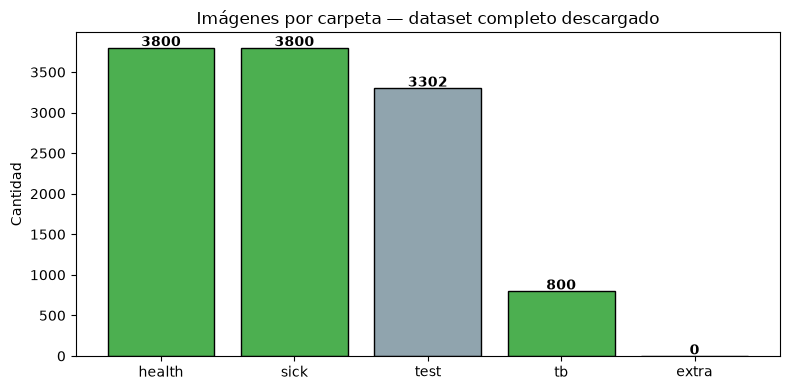

Verde = carpetas etiquetadas que usamos para entrenamiento
Gris  = test (sin etiquetas públicas) y extra (datasets externos adicionales)


In [7]:
# Vista agrupada por carpeta principal
por_carpeta = resumen_df.groupby('carpeta')['imagenes'].sum().sort_values(ascending=False)

colores_barras = ['#4CAF50' if c in ['health','sick','tb'] else '#90A4AE' for c in por_carpeta.index]

plt.figure(figsize=(8, 4))
bars = plt.bar(por_carpeta.index, por_carpeta.values, color=colores_barras, edgecolor='black')
for bar, cnt in zip(bars, por_carpeta.values):
    plt.text(bar.get_x() + bar.get_width()/2, cnt + 20, str(cnt), ha='center', fontweight='bold')
plt.title('Imágenes por carpeta — dataset completo descargado')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

print('Verde = carpetas etiquetadas que usamos para entrenamiento')
print('Gris  = test (sin etiquetas públicas) y extra (datasets externos adicionales)')

---
## 2. Balance de clases y dimensiones

Primero se revisa cuántas imágenes hay por clase y si están balanceadas. También se verifica si todas tienen el mismo tamaño y modo de color, porque eso afecta cualquier paso posterior.

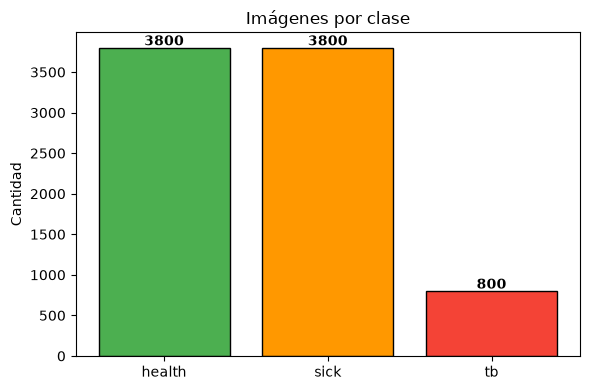

In [9]:
counts = df['class_name'].value_counts()
colores = ['#4CAF50', '#FF9800', '#F44336']

plt.figure(figsize=(6, 4))
bars = plt.bar(counts.index, counts.values, color=colores, edgecolor='black')
for bar, cnt in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, cnt + 30, str(cnt), ha='center', fontweight='bold')
plt.title('Imágenes por clase')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

In [10]:
print('Modos de color:')
print(df['modo'].value_counts())
print()
print('Resoluciones más frecuentes:')
print(df.groupby(['ancho', 'alto']).size().reset_index(name='cantidad')
        .sort_values('cantidad', ascending=False).head(10))

Modos de color:
modo
RGB    8400
Name: count, dtype: int64

Resoluciones más frecuentes:
   ancho  alto  cantidad
0    512   512      8400


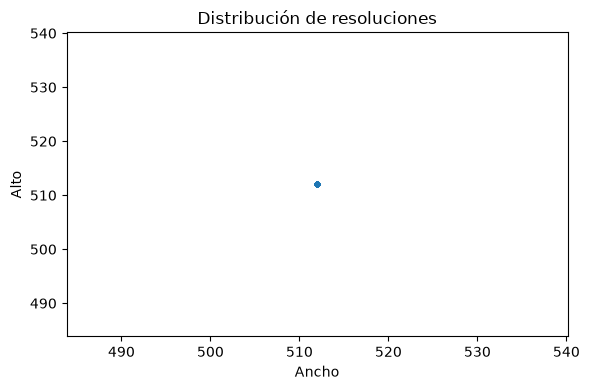

In [11]:
# Si hay imágenes fuera de las dimensiones normales aparecen como puntos aislados

plt.figure(figsize=(6, 4))
plt.scatter(df['ancho'], df['alto'], alpha=0.3, s=10)
plt.title('Distribución de resoluciones')
plt.xlabel('Ancho')
plt.ylabel('Alto')
plt.tight_layout()
plt.show()

---
## 3. Visualización de ejemplos por clase

Antes de cualquier cálculo, conviene ver cómo se ven las radiografías de cada clase. La pregunta es si hay diferencias visibles a ojo entre `health`, `sick` y `tb`.

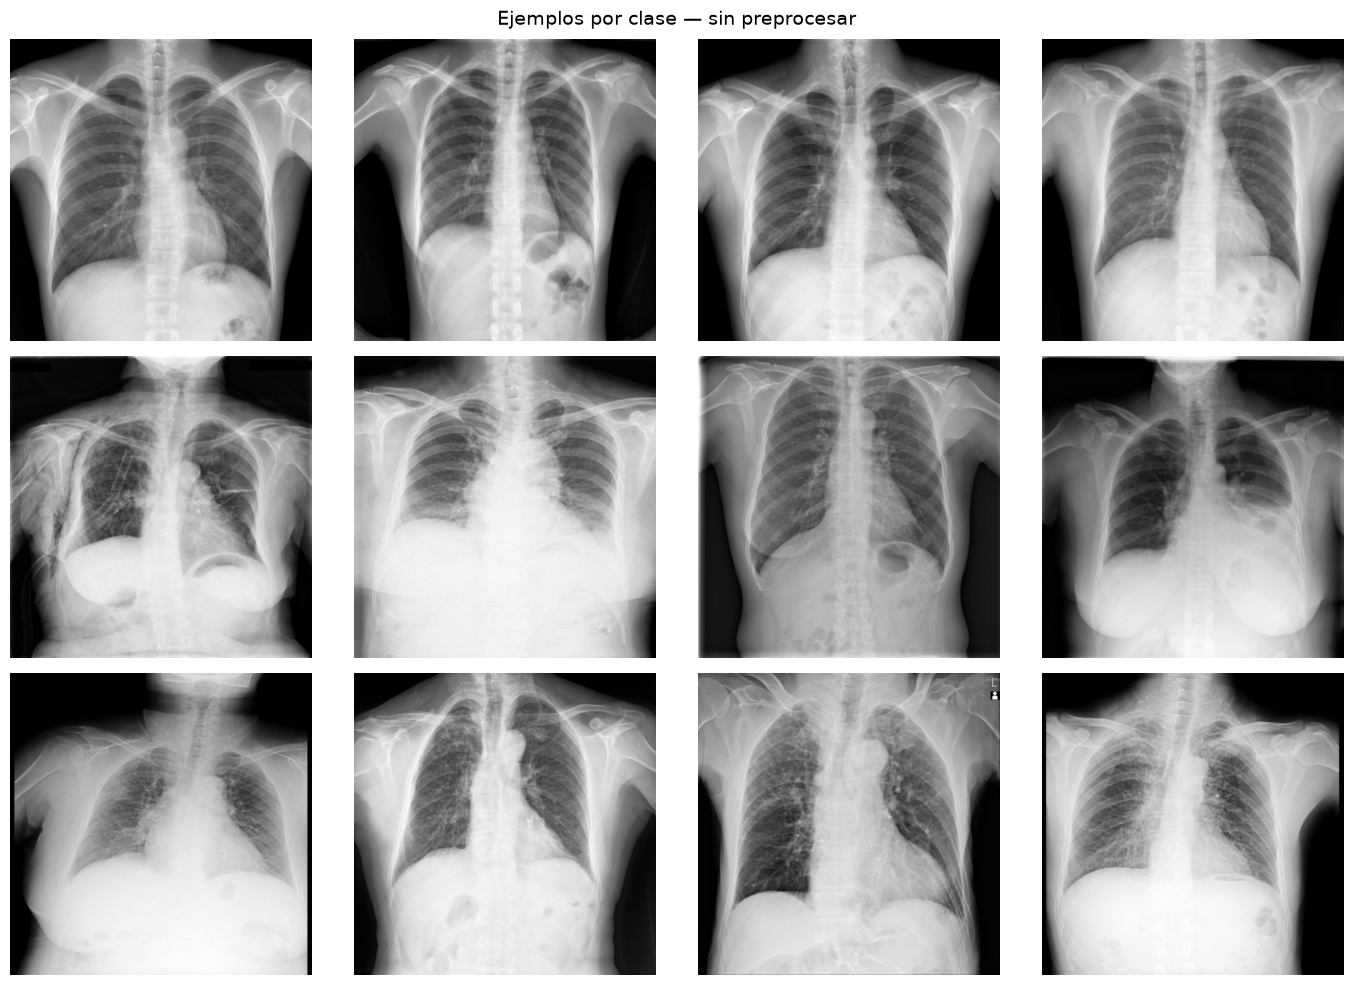

In [12]:
N_EJEMPLOS = 4

fig, axes = plt.subplots(3, N_EJEMPLOS, figsize=(14, 10))

for row, class_name in enumerate(['health', 'sick', 'tb']):
    muestras = df[df['class_name'] == class_name].sample(N_EJEMPLOS, random_state=42)
    for col, (_, sample) in enumerate(muestras.iterrows()):
        img = cv2.imread(sample['image_path'], cv2.IMREAD_GRAYSCALE)
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(class_name, fontsize=13, fontweight='bold')

plt.suptitle('Ejemplos por clase — sin preprocesar', fontsize=14)
plt.tight_layout()
plt.show()

---
## 4. Histogramas de intensidad por clase

El histograma de una imagen muestra cuántos píxeles hay de cada nivel de gris (0 = negro, 255 = blanco). Si los histogramas de `health` y `tb` se ven distintos, hay información útil en la distribución de brillo.

Las métricas de intensidad (mean, std, contrast, entropy) vienen de `CAD_Analisis_Exploratorio.ipynb`.

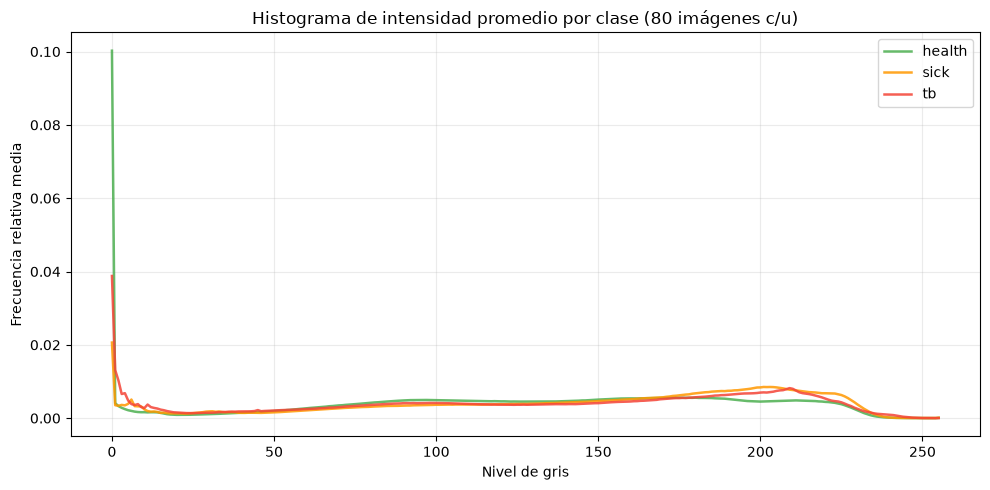

In [13]:
N_HIST = 80
colores_clase = {'health': '#4CAF50', 'sick': '#FF9800', 'tb': '#F44336'}

plt.figure(figsize=(10, 5))

for class_name, color in colores_clase.items():
    muestras = df[df['class_name'] == class_name].sample(N_HIST, random_state=42)
    hist_acum = np.zeros(256)
    for _, row in muestras.iterrows():
        img = cv2.imread(row['image_path'], cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        h = cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()
        hist_acum += h / h.sum()
    hist_acum /= N_HIST
    plt.plot(hist_acum, color=color, label=class_name, linewidth=1.8, alpha=0.85)

plt.title(f'Histograma de intensidad promedio por clase ({N_HIST} imágenes c/u)')
plt.xlabel('Nivel de gris')
plt.ylabel('Frecuencia relativa media')
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [14]:
stats = []
for class_name in ['health', 'sick', 'tb']:
    muestras = df[df['class_name'] == class_name].sample(N_HIST, random_state=42)
    for _, row in muestras.iterrows():
        img = cv2.imread(row['image_path'], cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        h = cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()
        h_norm = h / (h.sum() + 1e-9)
        stats.append({
            'class_name': class_name,
            'mean':       float(np.mean(img)),
            'std':        float(np.std(img)),
            'contrast':   float(np.max(img) - np.min(img)),
            'entropy':    float(entropy(h_norm + 1e-9)),
        })

stats_df = pd.DataFrame(stats)

print('Promedios por clase:')
print(stats_df.groupby('class_name')[['mean', 'std', 'contrast', 'entropy']].mean().round(2))

Promedios por clase:
              mean    std  contrast  entropy
class_name                                  
health      121.76  65.36    238.74     5.03
sick        143.27  61.79    231.66     5.11
tb          130.66  68.62    242.51     5.14


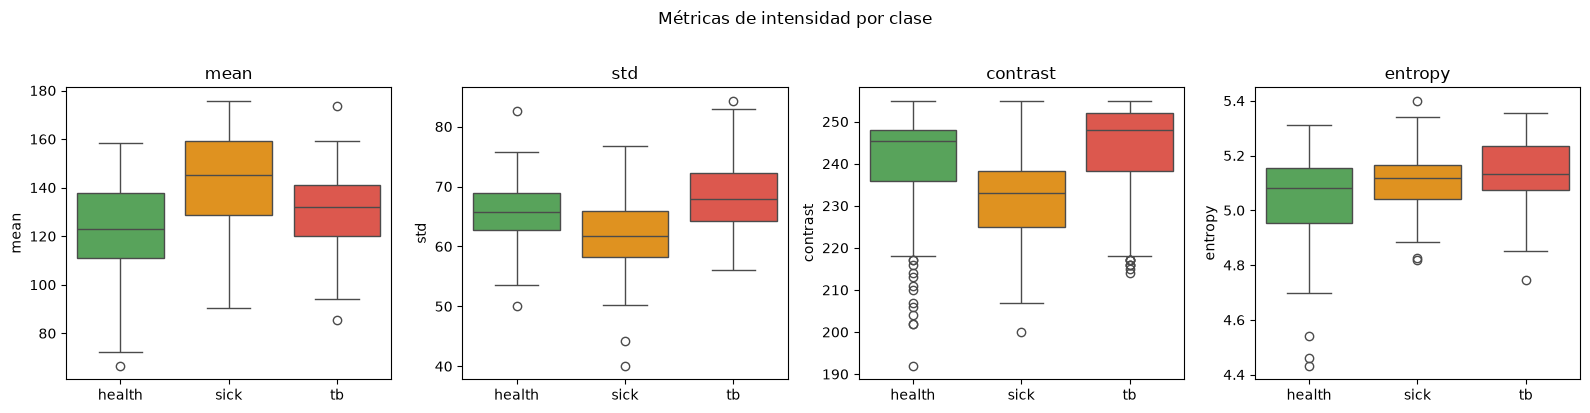

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
palette = {'health': '#4CAF50', 'sick': '#FF9800', 'tb': '#F44336'}

for ax, col in zip(axes, ['mean', 'std', 'contrast', 'entropy']):
    sns.boxplot(data=stats_df, x='class_name', y=col,
                order=['health', 'sick', 'tb'], palette=palette, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')

plt.suptitle('Métricas de intensidad por clase', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Preprocesamiento

Se aplica la cadena de preprocesamiento y se compara visualmente el antes y el después.

- **Bilateral Filter** — reduce el ruido granular sin borrar los bordes del tejido. Parámetros de `tbx11k-ensemble/BF.ipynb`.
- **CLAHE** — mejora el contraste local. En radiografías con zonas muy oscuras o muy claras ayuda a resaltar estructuras. Parámetros de `tbx11k-ensemble/CLAHE.ipynb`.

In [16]:
def preprocess(path: str) -> np.ndarray | None:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    img = cv2.bilateralFilter(img, d=9, sigmaColor=80, sigmaSpace=80)
    clahe = cv2.createCLAHE(clipLimit=40, tileGridSize=(8, 8))
    return clahe.apply(img)

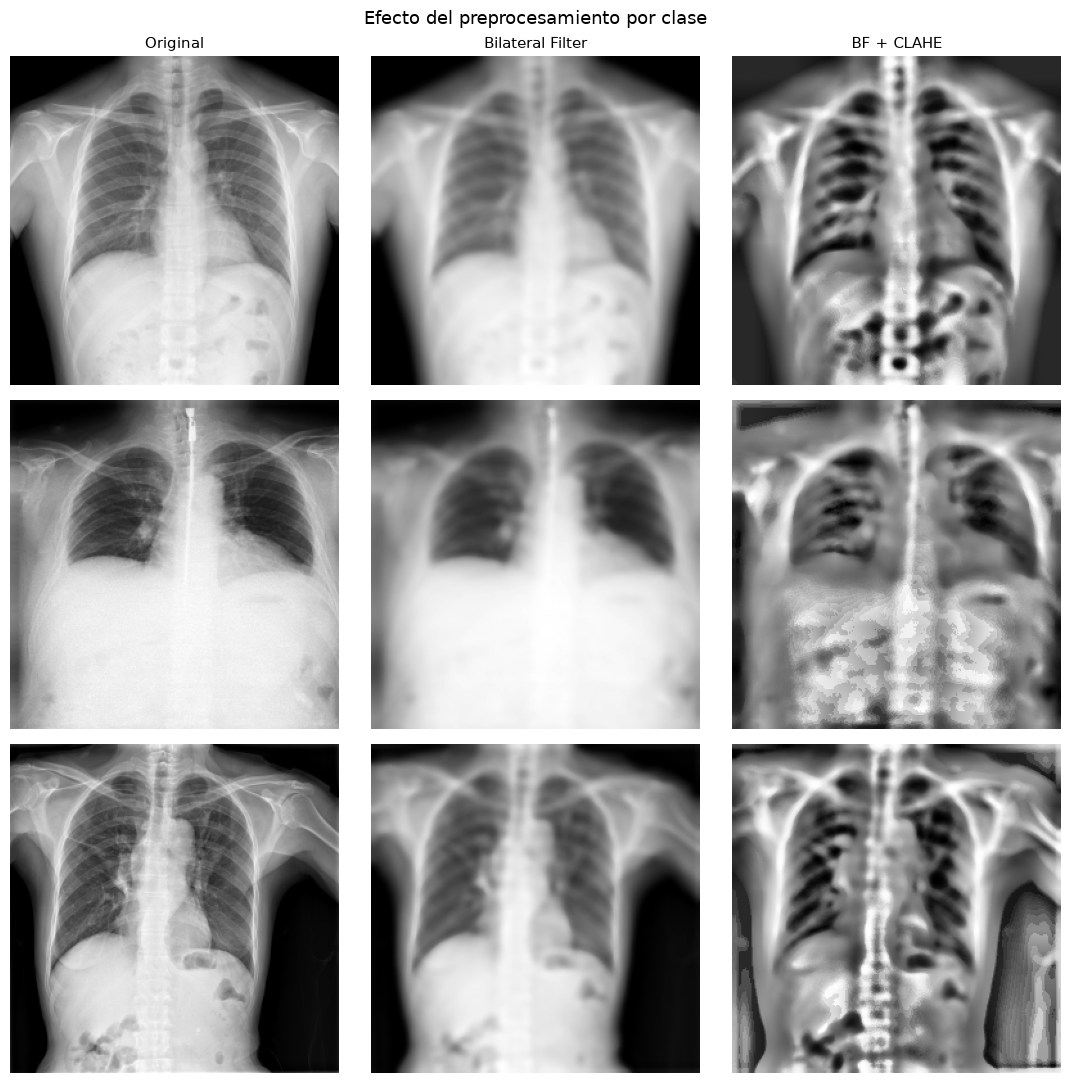

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(11, 11))
titulos = ['Original', 'Bilateral Filter', 'BF + CLAHE']

for row, class_name in enumerate(['health', 'sick', 'tb']):
    path = df[df['class_name'] == class_name].iloc[0]['image_path']

    original  = cv2.resize(cv2.imread(path, cv2.IMREAD_GRAYSCALE), IMG_SIZE)
    con_bf    = cv2.bilateralFilter(original, d=9, sigmaColor=80, sigmaSpace=80)
    con_clahe = cv2.createCLAHE(clipLimit=40, tileGridSize=(8, 8)).apply(con_bf)

    for col, img in enumerate([original, con_bf, con_clahe]):
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].axis('off')
        if row == 0:
            axes[row][col].set_title(titulos[col], fontsize=11)
        if col == 0:
            axes[row][col].set_ylabel(class_name, fontsize=11, fontweight='bold')

plt.suptitle('Efecto del preprocesamiento por clase', fontsize=13)
plt.tight_layout()
plt.show()

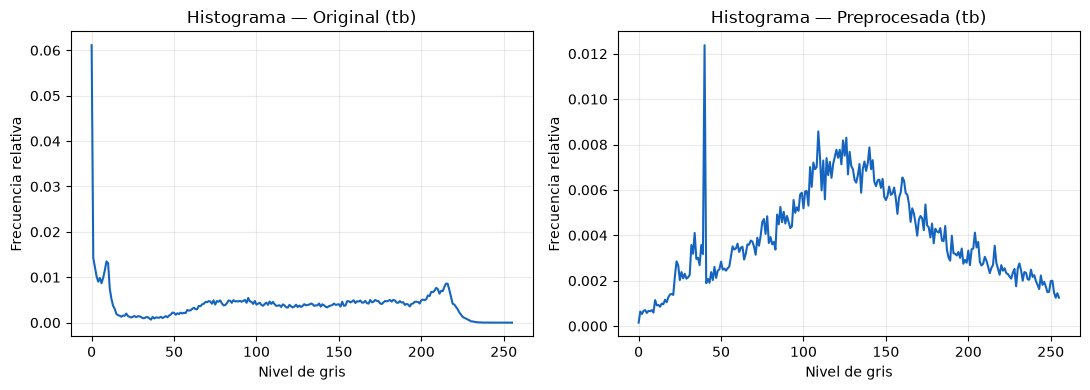

In [18]:
# El preprocesamiento cambia la distribución de intensidades.
# Se comparan los histogramas antes y después para una imagen de tb.

path_tb   = df[df['class_name'] == 'tb'].iloc[0]['image_path']
original  = cv2.resize(cv2.imread(path_tb, cv2.IMREAD_GRAYSCALE), IMG_SIZE)
procesada = preprocess(path_tb)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, img, titulo in zip(axes, [original, procesada], ['Original', 'Preprocesada']):
    h = cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()
    ax.plot(h / h.sum(), color='#1565C0', linewidth=1.5)
    ax.set_title(f'Histograma — {titulo} (tb)')
    ax.set_xlabel('Nivel de gris')
    ax.set_ylabel('Frecuencia relativa')
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

---
## 6. Análisis por zonas del pulmón

La tuberculosis activa tiende a afectar los lóbulos superiores del pulmón. Se divide la imagen en 6 regiones para ver si esa diferencia es visible en los datos.

La idea de dividir en regiones viene de `CAD_Analisis_Exploratorio.ipynb`. Las coordenadas se ajustaron para la imagen de 256×256.

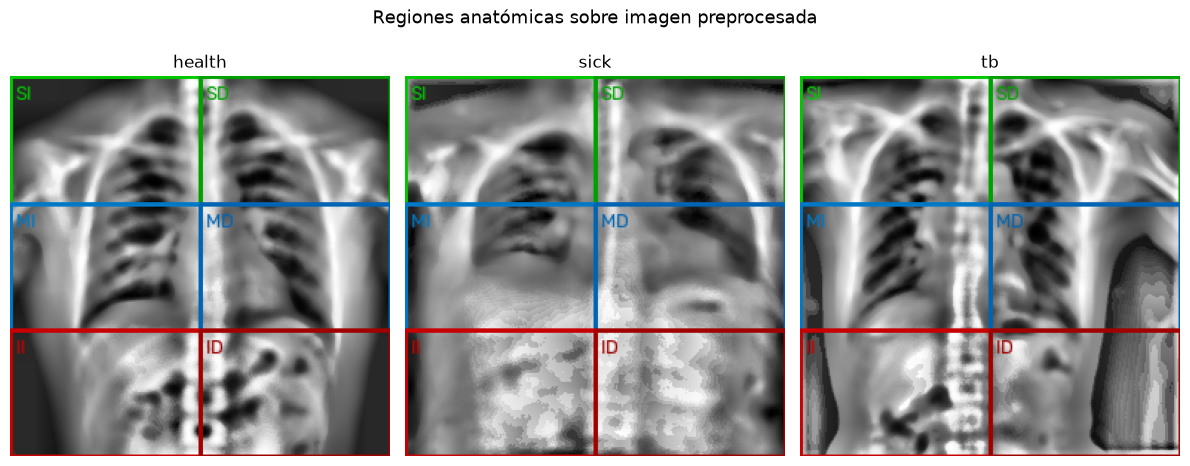

In [19]:
REGIONS = {
    'SI': (0,   0,   128, 86),
    'SD': (128, 0,   128, 86),
    'MI': (0,   86,  128, 85),
    'MD': (128, 86,  128, 85),
    'II': (0,   171, 128, 85),
    'ID': (128, 171, 128, 85),
}

fig, axes = plt.subplots(1, 3, figsize=(12, 5))
colores_region = [
    (0, 200, 0), (0, 160, 0),
    (200, 120, 0), (180, 100, 0),
    (0, 0, 200), (0, 0, 160),
]

for ax, class_name in zip(axes, ['health', 'sick', 'tb']):
    path    = df[df['class_name'] == class_name].iloc[0]['image_path']
    img_rgb = cv2.cvtColor(preprocess(path), cv2.COLOR_GRAY2BGR)

    for (name, (x, y, w, h)), color in zip(REGIONS.items(), colores_region):
        cv2.rectangle(img_rgb, (x, y), (x+w, y+h), color, 2)
        cv2.putText(img_rgb, name, (x+4, y+16), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

    ax.imshow(cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB))
    ax.set_title(class_name, fontsize=12)
    ax.axis('off')

plt.suptitle('Regiones anatómicas sobre imagen preprocesada', fontsize=13)
plt.tight_layout()
plt.show()

In [20]:
# Intensidad media por región y clase.
# Si tb tiene más brillo en SI y SD que health, hay un patrón clínicamente consistente.

N_REG = 60
reg_stats = []

for class_name in ['health', 'sick', 'tb']:
    muestras = df[df['class_name'] == class_name].sample(N_REG, random_state=42)
    for _, row in muestras.iterrows():
        img = preprocess(row['image_path'])
        if img is None:
            continue
        entry = {'class_name': class_name}
        for name, (x, y, w, h) in REGIONS.items():
            entry[f'{name}_mean'] = float(np.mean(img[y:y+h, x:x+w]))
        reg_stats.append(entry)

reg_df = pd.DataFrame(reg_stats)
region_cols = [f'{r}_mean' for r in REGIONS]

print('Intensidad media por región y clase:')
print(reg_df.groupby('class_name')[region_cols].mean().round(1))

Intensidad media por región y clase:
            SI_mean  SD_mean  MI_mean  MD_mean  II_mean  ID_mean
class_name                                                      
health        120.5    122.2    124.2    126.7    127.3    123.6
sick          126.8    127.6    126.6    130.1    144.6    139.1
tb            125.2    126.8    123.6    127.8    132.6    131.3


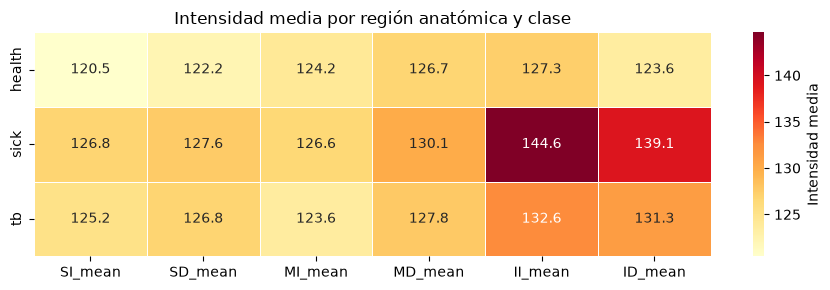

In [21]:
media_regional = reg_df.groupby('class_name')[region_cols].mean()

plt.figure(figsize=(9, 3))
sns.heatmap(media_regional, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Intensidad media'})
plt.title('Intensidad media por región anatómica y clase')
plt.ylabel('')
plt.tight_layout()
plt.show()

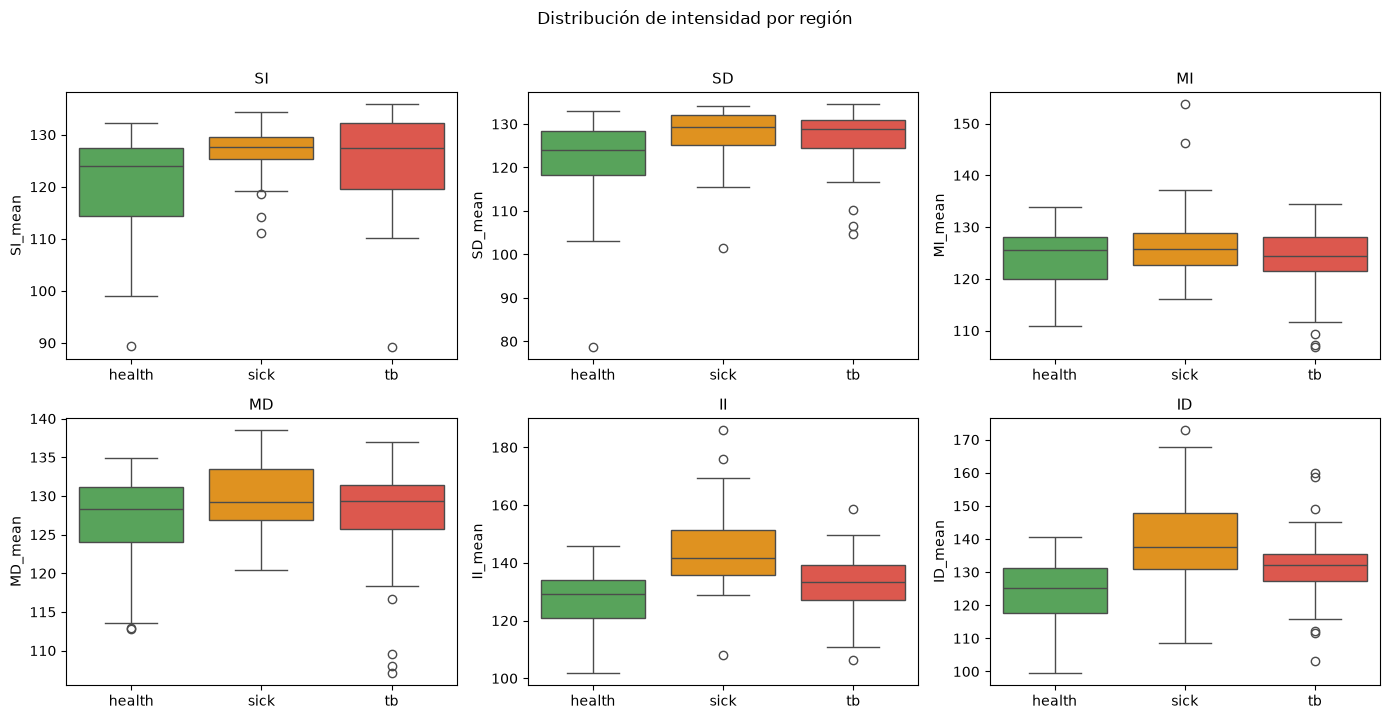

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for ax, col in zip(axes, region_cols):
    sns.boxplot(data=reg_df, x='class_name', y=col,
                order=['health', 'sick', 'tb'], palette=palette, ax=ax)
    ax.set_title(col.replace('_mean', ''), fontsize=11)
    ax.set_xlabel('')

plt.suptitle('Distribución de intensidad por región', y=1.02)
plt.tight_layout()
plt.show()